<a href="https://colab.research.google.com/github/nichmars/Test/blob/main/WeightedAveragePctChange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import io
import pandas as pd

# This line will prompt you to select and upload a file from your local machine
uploaded = files.upload()

# Get the name of the uploaded file (assuming only one file is uploaded)
file_name = next(iter(uploaded))

df = pd.read_excel(file_name)



Saving Filtered Data with Subtypes Again (1).xlsx to Filtered Data with Subtypes Again (1).xlsx


In [2]:
df = pd.read_excel(file_name)

df.replace('Single Issue', 'Single Issue Charity', inplace=True)

# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

group_totals = (
    df
    .groupby(["Year", "Type", "subtype"], as_index=False)[metrics]
    .sum()
)


group_totals = group_totals.sort_values(["Type", "subtype", "Year"])

group_totals["group_year_diff"] = (
    group_totals
    .groupby(["Type", "subtype"])["Year"]
    .diff()
)

for m in metrics:
    group_totals[f"group_{m.lower()}_growth"] = (
        group_totals
        .groupby(["Type", "subtype"])[m]
        .pct_change()
    )

    # Ignore non-consecutive group years
    group_totals.loc[
        group_totals["group_year_diff"] != 1,
        f"group_{m.lower()}_growth"
    ] = None

In [3]:
df = df.merge(
    group_totals[
        ["Year", "Type", "subtype"] +
        [f"group_{m.lower()}_growth" for m in metrics]
    ],
    on=["Year", "Type", "subtype"],
    how="left"
)

df = df.sort_values(["ein", "Year"])

df["ein_year_diff"] = df.groupby("ein")["Year"].diff()

for m in metrics:
    prev_actual = df.groupby("ein")[m].shift(1)

    df[f"predicted_{m.lower()}"] = prev_actual * (
        1 + df[f"group_{m.lower()}_growth"]
    )

    # Remove predictions when EIN years are not consecutive
    df.loc[df["ein_year_diff"] != 1, f"predicted_{m.lower()}"] = None

In [4]:
import numpy as np

# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions",  "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Function to calculate relative error for a column
def relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() & df[actual_col].notna() & (df[actual_col] != 0) & (df["ein_year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted))/total_actual).median()
    return RE

def relative_error_sum(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() & df[actual_col].notna() & (df[actual_col] != 0) & (df["ein_year_diff"] == 1)]
    total_actual = valid_rows[actual_col].sum()
    total_predicted = valid_rows[predicted_col].sum()
    RE = abs((total_actual - total_predicted))/total_actual
    return RE

def mean_relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() & df[actual_col].notna() & (df[actual_col] != 0) & (df["ein_year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted))/total_actual).mean()
    return RE

# Compute relative errors
RE_account = relative_error("Accounts", "predicted_accounts")
RE_contributions = relative_error("Contributions", "predicted_contributions")
RE_grants = relative_error("Grants", "predicted_grants")
RE_assets = relative_error("Assets", "predicted_assets")

RE_account2 = relative_error_sum("Accounts", "predicted_accounts")
RE_contributions2 = relative_error_sum("Contributions", "predicted_contributions")
RE_grants2 = relative_error_sum("Grants", "predicted_grants")
RE_assets2 = relative_error_sum("Assets", "predicted_assets")

RE_account3 = mean_relative_error("Accounts", "predicted_accounts")
RE_contributions3 = mean_relative_error("Contributions", "predicted_contributions")
RE_grants3 = mean_relative_error("Grants", "predicted_grants")
RE_assets3 = mean_relative_error("Assets", "predicted_assets")

print("Median Relative Deviation\n")
print("Median Relative Deviation - Account:", abs(RE_account))
print("Median Relative Deviation - Contributions:", abs(RE_contributions))
print("Median Relative Deviation - Grants:", abs(RE_grants))
print("Median Relative Deviation - Assets:", abs(RE_assets))

print("")
print("Aggregate Error - Account:", abs(RE_account2))
print("Aggregate Error - Contributions:", abs(RE_contributions2))
print("Aggregate Error - Grants:", abs(RE_grants2))
print("Aggregate Error - Assets:", abs(RE_assets2))

print("")
print("Mean Error - Account:", abs(RE_account3))
print("Mean Error - Contributions:", abs(RE_contributions3))
print("Mean Error - Grants:", abs(RE_grants3))
print("Mean Error - Assets:", abs(RE_assets3))


Median Relative Deviation

Median Relative Deviation - Account: 0.07260050159264814
Median Relative Deviation - Contributions: 0.5452940961085159
Median Relative Deviation - Grants: 0.3415999971579987
Median Relative Deviation - Assets: 0.1389850348523966

Aggregate Error - Account: 0.013486936206201854
Aggregate Error - Contributions: 0.0227576489820714
Aggregate Error - Grants: 0.02369093674751506
Aggregate Error - Assets: 0.026257098020433408

Mean Error - Account: 0.21702616074960923
Mean Error - Contributions: 3.5740649947420535
Mean Error - Grants: 2.313352359637323
Mean Error - Assets: 0.6441599427849574


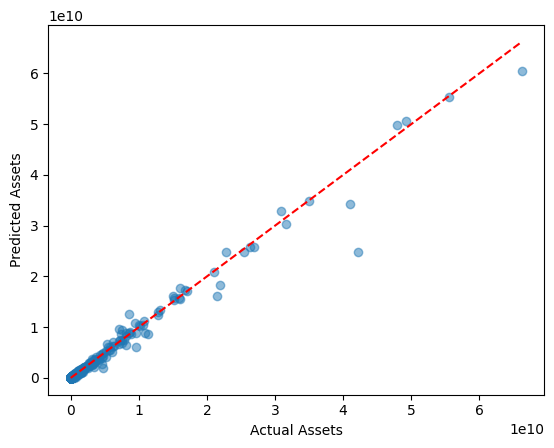

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df["Assets"], df["predicted_assets"], alpha=0.5)
plt.plot([0, df["Assets"].max()], [0, df["Assets"].max()], "r--")
plt.xlabel("Actual Assets")
plt.ylabel("Predicted Assets")
plt.show()

In [ ]:
#calculate error between each ein's actual and predicted

#valid_rows_Account = df[df["predicted_accounts"].notna()]



df["Actual Error Accounts"] = -(df["Accounts"] - df["predicted_accounts"])/df["Accounts"]
df["Actual Error Contributions"] = -(df["Contributions"] - df["predicted_contributions"])/df["Contributions"]
df["Actual Error Grants"] = -(df["Grants"] - df["predicted_grants"])/df["Grants"]
df["Actual Error Assets"] = -(df["Assets"] - df["predicted_assets"])/df["Assets"]


#df["Actual Error Accounts"].min()


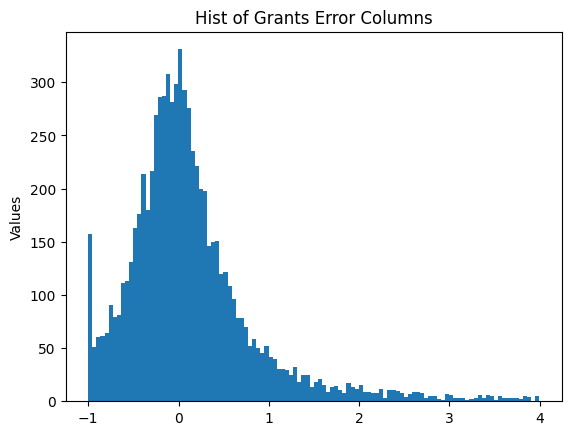

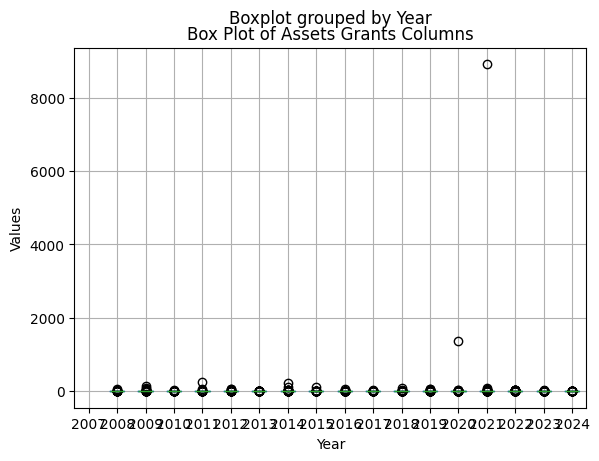

In [ ]:
filtered_df = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors = [x for x in filtered_df['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors)

#bins_arrayd = np.arange()
plt.hist(cleaned_errors, bins = 110)

plt.title("Hist of Grants Error Columns")
plt.ylabel("Values")
plt.show()

'''df.boxplot(column='Actual Error Contributions', by='Year')

plt.title("Box Plot of Contributions Error Columns")
plt.ylabel("Values")
plt.show()

df.boxplot(column='Actual Error Assets', by='Year')

plt.title("Box Plot of Assets Error Columns")
plt.ylabel("Values")
plt.show()'''

df.boxplot(column='Actual Error Grants', by='Year')

plt.title("Box Plot of Assets Grants Columns")
plt.ylabel("Values")
plt.show()

In [ ]:
filtered_df = df[~np.isinf(df['Actual Error Grants'])]
max_score_index = filtered_df['Actual Error Grants'].idxmax()

# Use .loc[] to retrieve the entire row as a Series
max_row = df.loc[max_score_index]

print("\nRow with the maximum Actual Error Grants:")
print(max_row)


Row with the maximum Actual Error Grants:
ein                                      132992977
Year                                          2021
Accounts                                        65
Contributions                             260938.0
Grants                                          16
Assets                                    260938.0
Type                          Single Issue Charity
subtype                                      Other
group_accounts_growth                     0.023698
group_contributions_growth               -0.090962
group_grants_growth                      -0.268124
group_assets_growth                       0.243712
ein_year_diff                                  1.0
predicted_accounts                       11.260679
predicted_contributions              381887.781519
predicted_grants                      142618.56211
predicted_assets                     610675.215542
Actual Error Accounts                    -0.826759
Actual Error Contributions             

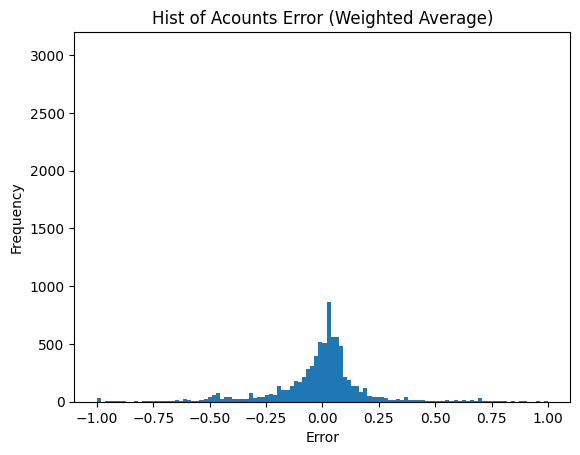

In [ ]:
df_error_accounts = df[~np.isinf(df['Actual Error Accounts'])]
cleaned_errors_accounts = [x for x in df_error_accounts['Actual Error Accounts'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_accounts)

plt.hist(cleaned_errors_accounts, bins = 110)

plt.title("Hist of Acounts Error (Weighted Average)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 3200) #
plt.show()

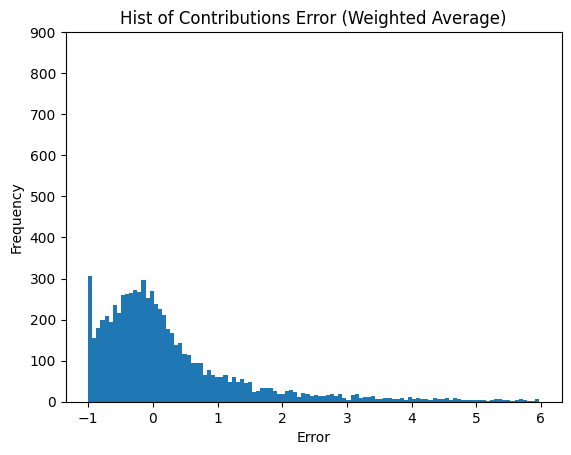

In [ ]:
df_error_contributions = df[~np.isinf(df['Actual Error Contributions'])]
cleaned_errors_contributions = [x for x in df_error_contributions['Actual Error Contributions'] if not np.isnan(x) and x < 6 ]

#print(cleaned_errors_contributions)

plt.hist(cleaned_errors_contributions, bins = 110)

plt.title("Hist of Contributions Error (Weighted Average)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 900) #
plt.show()

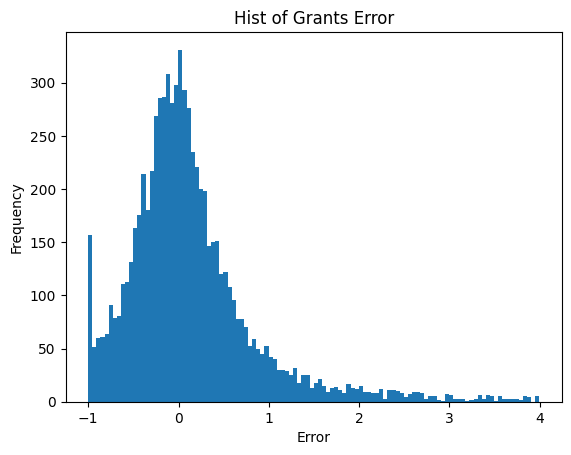

In [ ]:
df_error_grants = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors_grants = [x for x in df_error_grants['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors_grants)

plt.hist(cleaned_errors_grants, bins = 110)

plt.title("Hist of Grants Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

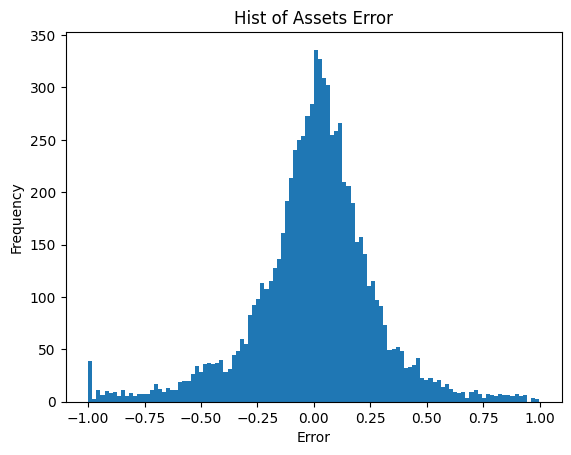

In [ ]:
df_error_assets = df[~np.isinf(df['Actual Error Assets'])]
cleaned_errors_assets = [x for x in df_error_assets['Actual Error Assets'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_assets)

plt.hist(cleaned_errors_assets, bins = 110)

plt.title("Hist of Assets Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

In [ ]:
df_eval = df[
    (df["Year"] >= 2019) & (df["Year"] <= 2024)
]

def relative_error(actual_col, predicted_col):
    valid_rows = df_eval[
        (df_eval["ein_year_diff"] == 1) &
        df_eval[predicted_col].notna() &
        df_eval[actual_col].notna() &
        (df_eval[actual_col] != 0)
    ]

    actual = valid_rows[actual_col]
    predicted = valid_rows[predicted_col]

    RE = (abs(actual - predicted) / actual).median()
    return RE


RE_account = relative_error("Accounts", "predicted_accounts")
RE_contributions = relative_error("Contributions", "predicted_contributions")
RE_grants = relative_error("Grants", "predicted_grants")
RE_assets = relative_error("Assets", "predicted_assets")

print("Median Relative Deviation - Account:", abs(RE_account))
print("Median Relative Deviation - Contributions:", abs(RE_contributions))
print("Median Relative Deviation - Grants:", abs(RE_grants))
print("Median Relative Deviation - Assets:", abs(RE_assets))

df_eval.head()

Median Relative Deviation - Account: 0.08271580212297215
Median Relative Deviation - Contributions: 0.543980744475776
Median Relative Deviation - Grants: 0.37102230291399524
Median Relative Deviation - Assets: 0.1298250653176904


,ein,Year,Accounts,Contributions,Grants,Assets,Type,subtype,group_accounts_growth,group_contributions_growth,group_grants_growth,group_assets_growth,ein_year_diff,predicted_accounts,predicted_contributions,predicted_grants,predicted_assets
12,10391479,2019,395,20802830.0,21188325,218364523.0,Community Foundation,Community,0.079576,-0.194554,-0.105049,0.167027,1.0,410.238856,2.374746e+07,1.879887e+07,2.264548e+08
13,10391479,2020,410,26448400.0,36253809,231757646.0,Community Foundation,Community,-0.005679,0.340271,0.495030,0.096289,1.0,392.756744,2.788143e+07,3.167718e+07,2.393907e+08
14,10391479,2021,440,44675962.0,21660094,294062119.0,Community Foundation,Community,0.026059,0.765752,0.120350,0.288463,1.0,420.684198,4.670131e+07,4.061695e+07,2.986112e+08
15,10391479,2022,440,26842585.0,42632358,244835865.0,Community Foundation,Community,0.042259,-0.223445,0.401530,-0.150965,1.0,458.593993,3.469336e+07,3.035728e+07,2.496692e+08
16,10391479,2023,456,33164528.0,44959811,257527475.0,Community Foundation,Community,0.082716,-0.272847,0.098100,0.003140,1.0,476.394953,1.951865e+07,4.681459e+07,2.456047e+08
